# Model Evaluation and Optimization

## 📚 Learning Objectives

By completing this notebook, you will:
- Conduct experiments and collect performance metrics
- Compare results with baseline or standard models
- Analyze failure cases and identify model weaknesses
- Visualize results using graphs, confusion matrices, and heat maps
- Run one refinement iteration (decision-threshold tuning) and measure whether it helped

## 🔗 Prerequisites

- ✅ Unit 3: Model development completed
- ✅ Trained models ready for evaluation
- ✅ Understanding of evaluation metrics

---

This notebook covers practical activities from **Course 12, Unit 4**:
- Conducting experiments and collecting performance metrics
- Comparing results against a standard baseline model (logistic regression)
- Analyzing failure cases and identifying weaknesses in the model
- Visualizing results using graphs, confusion matrices, or heat maps
- Iteratively improving the model — demonstrated here with decision-threshold tuning

---

## Introduction

**Model Evaluation and Optimization** involves comprehensive analysis of model performance, identifying areas for improvement, and iteratively refining the model. Throughout this notebook we follow the discipline from Unit 3: models are compared and refined on the **validation** set, and the **test** set is used exactly once, at the very end.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Import everything used below: models, splitting, curve/matrix utilities and
# the four headline metrics — all imports in one place so every cell can use them.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                            roc_curve, auc, precision_recall_curve,
                            accuracy_score, precision_score, recall_score, f1_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Generate a synthetic dataset and make a THREE-way split so each job gets its
# own data: train to fit, validation to compare/refine, test for one final check
# (the discipline taught in Unit 3, notebook 01).
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# First carve off the untouched test set (20% of all data)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Then split what remains into training (60% overall) and validation (20% overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print("📝 Models are compared and refined on the VALIDATION set")
print("📝 The TEST set is used exactly once, at the very end")

Training: (600, 20), Validation: (200, 20), Test: (200, 20)
📝 Models are compared and refined on the VALIDATION set
📝 The TEST set is used exactly once, at the very end


## Part 1: Model Comparison - Multiple Algorithms

Compare different algorithms **on the validation set** to select the best
approach. Selecting on the test set would leak information and inflate the
final numbers — remember the rule from Unit 3: *use the test set ONLY for
final evaluation*.

In [3]:
# Train three candidate algorithms and compare them on the VALIDATION set —
# choosing a model is a modeling decision, so it must not touch the test set.
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}

print("=" * 60)
print("Model Comparison (validation set)")
print("=" * 60)

for name, model in models.items():
    # Fit on the training set only
    model.fit(X_train, y_train)

    # Predict labels and class-1 probabilities on the validation set
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]  # all three models support predict_proba

    # Record the four headline metrics plus raw predictions for later analysis
    results[name] = {
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'predictions': y_pred,
        'probabilities': y_proba
    }

    print(f"\n{name}:")
    print(f"  Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall:    {results[name]['recall']:.4f}")
    print(f"  F1-Score:  {results[name]['f1']:.4f}")

# Select the winner by validation F1 (balances precision and recall)
best_model_name = max(results, key=lambda x: results[x]['f1'])
print(f"\n✅ Best Model (validation F1): {best_model_name} ({results[best_model_name]['f1']:.4f})")

Model Comparison (validation set)

Logistic Regression:
  Accuracy:  0.9000
  Precision: 0.9348
  Recall:    0.8600
  F1-Score:  0.8958

Random Forest:
  Accuracy:  0.9200
  Precision: 0.9468
  Recall:    0.8900
  F1-Score:  0.9175

SVM:
  Accuracy:  0.8900
  Precision: 0.9432
  Recall:    0.8300
  F1-Score:  0.8830

✅ Best Model (validation F1): Random Forest (0.9175)


## Part 2: Confusion Matrix and ROC Curve Visualization

Visualize the validation-set performance: a confusion-matrix heat map for the
selected model, ROC curves for every candidate, and the selected model's
precision-recall curve.

Confusion matrix (Random Forest, validation set):
True Negatives: 95, False Positives: 5
False Negatives: 11, True Positives: 89


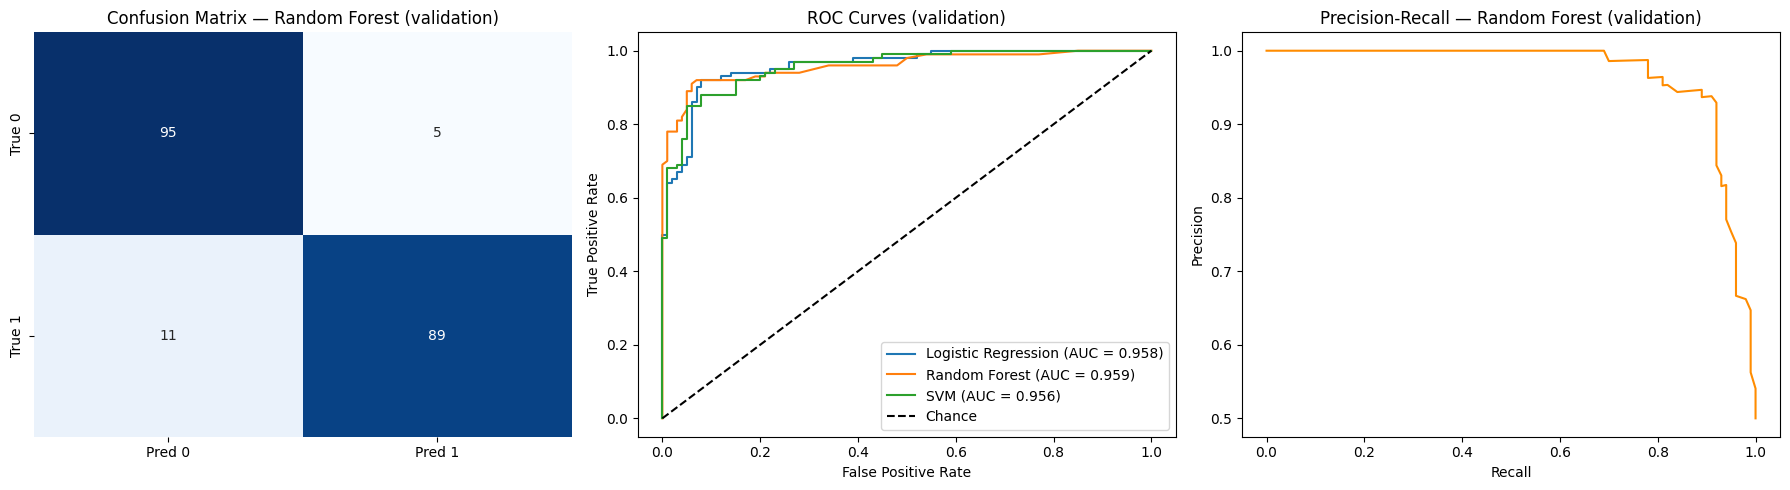


ROC AUC (Random Forest, validation): 0.9594


In [4]:
# Visualize validation performance: heat map of the winner's confusion matrix,
# ROC curves for all candidates, and the winner's precision-recall curve.
best_val_pred = results[best_model_name]['predictions']
cm = confusion_matrix(y_val, best_val_pred)

# Print the raw confusion-matrix cells for reference alongside the figure
print(f"Confusion matrix ({best_model_name}, validation set):")
print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: confusion-matrix heat map (counts annotated in each cell)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[0].set_title(f'Confusion Matrix — {best_model_name} (validation)')

# Panel 2: ROC curves for ALL candidates on one axis (higher curve = better)
for name in results:
    fpr, tpr, _ = roc_curve(y_val, results[name]['probabilities'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label='Chance')  # diagonal = random guessing
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (validation)')
axes[1].legend()

# Panel 3: precision-recall curve for the selected model
prec, rec, _ = precision_recall_curve(y_val, results[best_model_name]['probabilities'])
axes[2].plot(rec, prec, color='darkorange')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title(f'Precision-Recall — {best_model_name} (validation)')

plt.tight_layout()
plt.show()

# Headline number: the selected model's ROC AUC on validation
best_fpr, best_tpr, _ = roc_curve(y_val, results[best_model_name]['probabilities'])
print(f"\nROC AUC ({best_model_name}, validation): {auc(best_fpr, best_tpr):.4f}")

## Part 3: Failure Case Analysis

Analyze where and why the selected model fails — on the **validation** set,
since failure analysis guides improvement and must not mine the test set.

In [5]:
# Break the validation errors into false positives / false negatives and look
# at the model's confidence on each: errors near 0.5 are 'unsure', errors far
# from 0.5 are confidently wrong and worth a closer look in your own project.
predictions = results[best_model_name]['predictions']
probs = results[best_model_name]['probabilities']

# Count the misclassified validation samples
misclassified_indices = np.where(predictions != y_val)[0]

print("=" * 60)
print("Failure Case Analysis (validation set)")
print("=" * 60)
print(f"Total validation samples: {len(y_val)}")
print(f"Correctly classified: {np.sum(predictions == y_val)}")
print(f"Misclassified: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_val)*100:.2f}%)")

# Separate the two error types
false_positives = np.where((predictions == 1) & (y_val == 0))[0]
false_negatives = np.where((predictions == 0) & (y_val == 1))[0]

print(f"\nFalse Positives (Type I errors): {len(false_positives)}")
print(f"False Negatives (Type II errors): {len(false_negatives)}")

# Average predicted probability of class 1 for each error type
if len(false_positives) > 0:
    print(f"\nFalse Positive Analysis:")
    print(f"  Average confidence: {np.mean(probs[false_positives]):.4f}")
    print(f"  These samples were predicted as positive but are actually negative")

if len(false_negatives) > 0:
    print(f"\nFalse Negative Analysis:")
    print(f"  Average confidence: {np.mean(probs[false_negatives]):.4f}")
    print(f"  These samples were predicted as negative but are actually positive")

print("\n✅ Use failure case analysis to:")
print("  - Identify data quality issues")
print("  - Improve feature engineering")
print("  - Adjust class weights or thresholds")
print("  - Collect more training data for difficult cases")

Failure Case Analysis (validation set)
Total validation samples: 200
Correctly classified: 184
Misclassified: 16 (8.00%)

False Positives (Type I errors): 5
False Negatives (Type II errors): 11

False Positive Analysis:
  Average confidence: 0.6960
  These samples were predicted as positive but are actually negative

False Negative Analysis:
  Average confidence: 0.2464
  These samples were predicted as negative but are actually positive

✅ Use failure case analysis to:
  - Identify data quality issues
  - Improve feature engineering
  - Adjust class weights or thresholds
  - Collect more training data for difficult cases


## Part 4: One Refinement Iteration — Decision Threshold Tuning

Evaluation is not the end: you act on it. The cheapest refinement is moving
the decision threshold: `predict_proba` gives a probability, and 0.5 is only
the *default* cut-off. We pick the threshold that maximizes F1 on the
validation set — still without touching the test set — and keep it only if it
actually helps.

In [6]:
# Refinement iteration: search the decision threshold that maximizes F1 on the
# validation set (a parameter of the DECISION, not of the trained model).
probs_val = results[best_model_name]['probabilities']

# Every candidate threshold comes from the precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_val, probs_val)
# F1 at each threshold (guard against 0/0 with a tiny denominator floor);
# the last precision/recall point has no threshold, so drop it
f1_scores = 2 * precisions * recalls / np.maximum(precisions + recalls, 1e-12)
best_idx = int(np.argmax(f1_scores[:-1]))
best_threshold = float(thresholds[best_idx])

# Compare the default 0.5 cut-off against the tuned one — both on validation
default_f1 = f1_score(y_val, (probs_val >= 0.5).astype(int))
tuned_f1 = f1_score(y_val, (probs_val >= best_threshold).astype(int))

print("=" * 60)
print("Refinement: decision-threshold tuning (validation set)")
print("=" * 60)
print(f"Best threshold found: {best_threshold:.3f}")
print(f"F1 at default 0.50 threshold: {default_f1:.4f}")
print(f"F1 at tuned threshold:        {tuned_f1:.4f}")
print(f"Change: {tuned_f1 - default_f1:+.4f}")

# Keep the tuned threshold only if it genuinely helped on validation
chosen_threshold = best_threshold if tuned_f1 > default_f1 else 0.5
if chosen_threshold == 0.5:
    print("\nDecision: tuning did not beat the default — keep threshold 0.50")
else:
    print(f"\nDecision: adopt the tuned threshold {chosen_threshold:.3f} for the final evaluation")

Refinement: decision-threshold tuning (validation set)
Best threshold found: 0.410
F1 at default 0.50 threshold: 0.9175
F1 at tuned threshold:        0.9246
Change: +0.0071

Decision: adopt the tuned threshold 0.410 for the final evaluation


## Part 5: Final Evaluation on the Untouched Test Set

Every decision so far — which model, which threshold — used only training and
validation data. Now, **once**, we measure the finished system on the test
set. This is the number that goes in your report.

In [7]:
# The single final evaluation: apply the selected model + chosen threshold to
# the test set, which no decision so far has touched.
final_model = models[best_model_name]
probs_test = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (probs_test >= chosen_threshold).astype(int)

# Headline metrics on the untouched test set
print("=" * 60)
print(f"Final test evaluation: {best_model_name} @ threshold {chosen_threshold:.2f}")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")

# Apples-to-apples check: validation F1 at the SAME threshold vs test F1.
# A small gap means the validation estimate held up on unseen data.
val_f1_chosen = f1_score(y_val, (probs_val >= chosen_threshold).astype(int))
test_f1 = f1_score(y_test, y_test_pred)
gap = test_f1 - val_f1_chosen
print(f"\nValidation F1: {val_f1_chosen:.4f}  |  Test F1: {test_f1:.4f}  (gap {gap:+.4f})")

# Compute the interpretation from the gap instead of asserting it in prose
if abs(gap) < 0.03:
    print("Interpretation: test performance is close to validation — the estimate held up.")
elif gap < 0:
    print("Interpretation: test is noticeably below validation — our choices overfit the")
    print("validation set somewhat; report the test number, and do not re-tune on it.")
else:
    print("Interpretation: test came out above validation — likely sampling noise on")
    print("small splits; report the test number as-is.")

print("\n📝 This is the number that goes in your report — and the test set is now spent.")

Final test evaluation: Random Forest @ threshold 0.41
Accuracy:  0.9000
Precision: 0.8846
Recall:    0.9200
F1-Score:  0.9020

Validation F1: 0.9246  |  Test F1: 0.9020  (gap -0.0227)
Interpretation: test performance is close to validation — the estimate held up.

📝 This is the number that goes in your report — and the test set is now spent.


## Summary

### Key Evaluation Steps:
1. **Three-way split first**: train to fit, validation to compare and refine, test for one final measurement
2. **Multiple Algorithms**: compare candidates on the validation set and select by one agreed metric
3. **Comprehensive Metrics**: accuracy, precision, recall, F1, ROC-AUC
4. **Visualization**: confusion-matrix heat map, ROC curves, precision-recall curve (all rendered above)
5. **Failure Analysis**: break errors into FP/FN and inspect the model's confidence on each
6. **One refinement iteration**: decision-threshold tuning on validation, kept only if it helped
7. **Final test evaluation**: the test set is used exactly once, and its number is what you report

### Optimization Strategies (for your own project):
- **Data**: collect more data, improve data quality, feature engineering
- **Model**: try different architectures, ensemble methods
- **Hyperparameters**: optimize with the CV-based searches from Unit 3
- **Thresholds**: adjust decision thresholds for the precision/recall trade-off (demonstrated above)

**Reference:** Course 12, Unit 4: "Evaluation and Refinement" — reuse the evaluation
workflow above on your capstone project.

## 📚 References

1. Fawcett, T. (2006). *An introduction to ROC analysis*. Pattern Recognition Letters, 27(8), 861–874. <https://doi.org/10.1016/j.patrec.2005.10.010>
2. Raschka, S. (2018). *Model Evaluation, Model Selection, and Algorithm Selection in Machine Learning*. arXiv. <https://arxiv.org/abs/1811.12808>
3. D'Amour, A., Heller, K., Moldovan, D., et al. (2020). *Underspecification Presents Challenges for Credibility in Modern Machine Learning*. arXiv. <https://arxiv.org/abs/2011.03395>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 5: Resampling Methods. Springer.